## Transform data from PX4 Autopilot coordinates to VTK

To transform data from OpenCV to VTK, you need to consider the differences in how each library typically handles coordinate systems. OpenCV uses a left-handed coordinate system, primarily for image data, where:

- The **X-axis** goes from left to right.
- The **Y-axis** goes from top to bottom.
- The **Z-axis** (if used in 3D contexts, like in computer vision) typically goes into the screen.

On the other hand, as previously described, VTK uses a right-handed coordinate system.

To transform a point from OpenCV coordinates $[a, b, c]$ to VTK coordinates, you would typically need to flip the Y and Z axes. The transformation matrix that achieves this in a 3x3 format (assuming no scaling, and $c$ in OpenCV translates directly as depth information) is:

$
\begin{bmatrix}
1 & 0 & 0 \\
0 & -1 & 0 \\
0 & 0 & -1
\end{bmatrix}
$

Here's how this matrix works:

- **X-axis** remains unchanged: $x_{vtk} = x_{opencv}$.
- **Y-axis** is inverted: $y_{vtk} = -y_{opencv}$.
- **Z-axis** is also inverted (to maintain right-handedness with the new Y-axis orientation): $z_{vtk} = -z_{opencv}$.

Thus, if you have a point $[a, b, c]$ in OpenCV, the corresponding point in VTK would be $[a, -b, -c]$. This matrix only handles the transformation of the coordinates. If you also need to translate (move the origin), you might need to use a 4x4 transformation matrix, which can incorporate translation vectors as well.


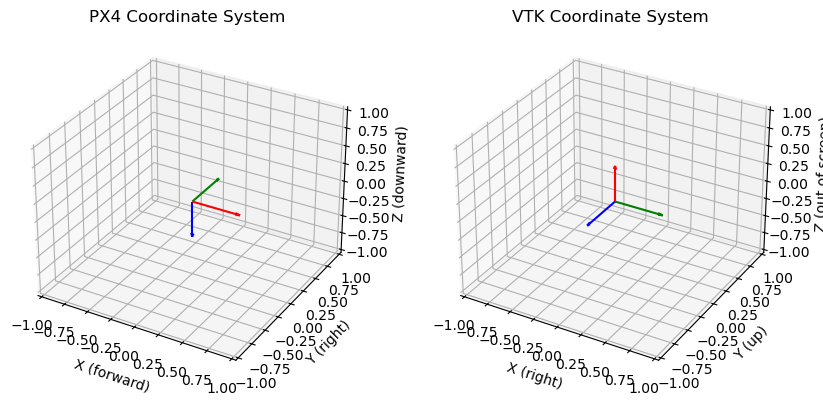

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Function to draw a vector
def draw_vector(ax, start, end, color):
    arrow = np.array(end) - np.array(start)
    ax.quiver(start[0], start[1], start[2], arrow[0], arrow[1], arrow[2],
              arrow_length_ratio=0.1, color=color)

# Set up the figure and 3D axis for PX4 and VTK with transformations
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Limits and labels for PX4 Autopilot axis (right-handed coordinate system)
ax1.set_xlim([-1, 1])
ax1.set_ylim([-1, 1])
ax1.set_zlim([-1, 1])
ax1.set_xlabel('X (forward)')
ax1.set_ylabel('Y (right)')
ax1.set_zlabel('Z (downward)')
ax1.set_title('PX4 Coordinate System')

# Limits and labels for VTK axis (right-handed coordinate system)
ax2.set_xlim([-1, 1])
ax2.set_ylim([-1, 1])
ax2.set_zlim([-1, 1])
ax2.set_xlabel('X (right)')
ax2.set_ylabel('Y (up)')
ax2.set_zlabel('Z (out of screen)')
ax2.set_title('VTK Coordinate System')

# Draw PX4 Autopilot coordinate frame
draw_vector(ax1, [0, 0, 0], [0.5, 0, 0], 'r')  # X-axis in red
draw_vector(ax1, [0, 0, 0], [0, 0.5, 0], 'g')  # Y-axis in green
draw_vector(ax1, [0, 0, 0], [0, 0, -0.5], 'b')  # Z-axis in blue (pointing down)

# Draw VTK coordinate frame after transformation
# PX4 X-axis becomes VTK Z-axis
draw_vector(ax2, [0, 0, 0], [0, 0, 0.5], 'r')  # Z-axis in red
# PX4 Y-axis becomes VTK X-axis
draw_vector(ax2, [0, 0, 0], [0.5, 0, 0], 'g')  # X-axis in green
# PX4 Z-axis (inverted) becomes VTK Y-axis
draw_vector(ax2, [0, 0, 0], [0, -0.5, 0], 'b')  # Y-axis in blue

# Show plot
plt.show()


## Transform data from PX4 Autopilot coordinates to VTK

To properly transform data from PX4 Autopilot coordinates to VTK, it's essential to understand the coordinate system conventions used by both. PX4 Autopilot uses a right-handed coordinate system, typically as follows for its local frame:

- **X-axis** points forward.
- **Y-axis** points to the right.
- **Z-axis** points downward (which is a common convention in aerial and maritime navigation to keep Z positive in altitude above a reference, such as sea level).

In contrast, VTK uses:

- **X-axis** pointing right.
- **Y-axis** pointing up.
- **Z-axis** pointing out of the screen.

To transform a point from PX4 Autopilot coordinates $[x, y, z]$ to VTK coordinates, we need to align these axes properly. Based on the conventions:

- **PX4 X-axis** (forward) should map to the **VTK Z-axis** (out of the screen for forward in most visualization contexts).
- **PX4 Y-axis** (right) should map to the **VTK X-axis** (right).
- **PX4 Z-axis** (down) should be inverted to match the **VTK Y-axis** (up).

The transformation matrix to accomplish this in a 3x3 format is:

$
\begin{bmatrix}
0 & 1 & 0 \\
0 & 0 & -1 \\
1 & 0 & 0
\end{bmatrix}
$

This matrix translates the axes as follows:

- $x_{vtk} = y_{px4}$ (PX4 Y-axis becomes VTK X-axis)
- $y_{vtk} = -z_{px4}$ (PX4 Z-axis is inverted to become VTK Y-axis)
- $z_{vtk} = x_{px4}$ (PX4 X-axis becomes VTK Z-axis)

Therefore, if you have a point $[x, y, z]$ in PX4 Autopilot coordinates, it would be transformed to $[y, -z, x]$ in VTK coordinates. This transformation properly aligns the coordinate systems between PX4's flight-oriented frame and VTK's visualization-oriented frame.


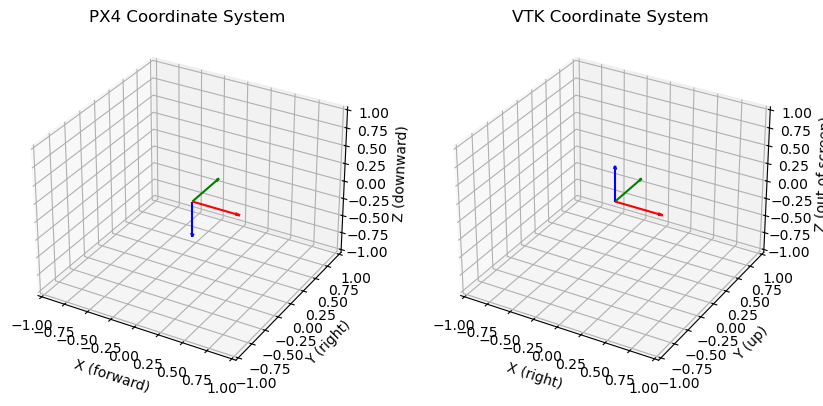

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Function to draw a vector
def draw_vector(ax, start, end, color):
    arrow = np.array(end) - np.array(start)
    ax.quiver(start[0], start[1], start[2], arrow[0], arrow[1], arrow[2],
              arrow_length_ratio=0.1, color=color)

# Set up the figure and 3D axis for PX4 and VTK
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Limits and labels for PX4 Autopilot axis (right-handed coordinate system)
ax1.set_xlim([-1, 1])
ax1.set_ylim([-1, 1])
ax1.set_zlim([-1, 1])
ax1.set_xlabel('X (forward)')
ax1.set_ylabel('Y (right)')
ax1.set_zlabel('Z (downward)')
ax1.set_title('PX4 Coordinate System')

# Limits and labels for VTK axis (right-handed coordinate system)
ax2.set_xlim([-1, 1])
ax2.set_ylim([-1, 1])
ax2.set_zlim([-1, 1])
ax2.set_xlabel('X (right)')
ax2.set_ylabel('Y (up)')
ax2.set_zlabel('Z (out of screen)')
ax2.set_title('VTK Coordinate System')

# Draw PX4 Autopilot coordinate frame
draw_vector(ax1, [0, 0, 0], [0.5, 0, 0], 'r')  # X-axis in red
draw_vector(ax1, [0, 0, 0], [0, 0.5, 0], 'g')  # Y-axis in green
draw_vector(ax1, [0, 0, 0], [0, 0, -0.5], 'b')  # Z-axis in blue (pointing down)

# Draw VTK coordinate frame
draw_vector(ax2, [0, 0, 0], [0.5, 0, 0], 'r')  # X-axis in red
draw_vector(ax2, [0, 0, 0], [0, 0.5, 0], 'g')  # Y-axis in green
draw_vector(ax2, [0, 0, 0], [0, 0, 0.5], 'b')  # Z-axis in blue (pointing out of screen)

# Show plot
plt.show()


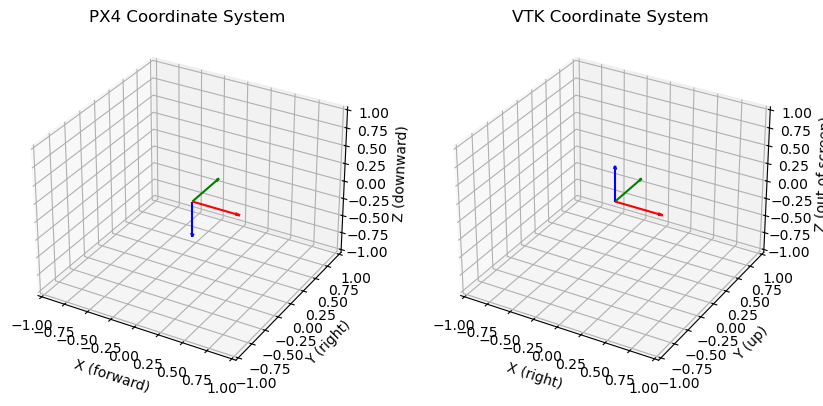

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Function to draw a vector
def draw_vector(ax, start, end, color):
    arrow = np.array(end) - np.array(start)
    ax.quiver(start[0], start[1], start[2], arrow[0], arrow[1], arrow[2],
              arrow_length_ratio=0.1, color=color)

# Set up the figure and 3D axis for PX4 and VTK
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Limits and labels for PX4 Autopilot axis (right-handed coordinate system)
ax1.set_xlim([-1, 1])
ax1.set_ylim([-1, 1])
ax1.set_zlim([-1, 1])
ax1.set_xlabel('X (forward)')
ax1.set_ylabel('Y (right)')
ax1.set_zlabel('Z (downward)')
ax1.set_title('PX4 Coordinate System')

# Limits and labels for VTK axis (right-handed coordinate system)
ax2.set_xlim([-1, 1])
ax2.set_ylim([-1, 1])
ax2.set_zlim([-1, 1])
ax2.set_xlabel('X (right)')
ax2.set_ylabel('Y (up)')
ax2.set_zlabel('Z (out of screen)')
ax2.set_title('VTK Coordinate System')

# Draw PX4 Autopilot coordinate frame
draw_vector(ax1, [0, 0, 0], [0.5, 0, 0], 'r')  # X-axis in red
draw_vector(ax1, [0, 0, 0], [0, 0.5, 0], 'g')  # Y-axis in green
draw_vector(ax1, [0, 0, 0], [0, 0, -0.5], 'b')  # Z-axis in blue (pointing down)

# Draw VTK coordinate frame
draw_vector(ax2, [0, 0, 0], [0.5, 0, 0], 'r')  # X-axis in red
draw_vector(ax2, [0, 0, 0], [0, 0.5, 0], 'g')  # Y-axis in green
draw_vector(ax2, [0, 0, 0], [0, 0, 0.5], 'b')  # Z-axis in blue (pointing out of screen)

# Show plot
plt.show()


## Transform data from PX4 Autopilot coordinates to OpenGL

OpenCV typically uses a coordinate system where the origin is at the top-left corner of the image, the X-axis points to the right, the Y-axis points downwards, and the Z-axis (in the case of 3D operations) points forwards out of the image plane.

OpenGL, on the other hand, uses a right-handed coordinate system for its default 3D space: the X-axis points to the right, the Y-axis points up, and the Z-axis points out of the screen (i.e., towards the viewer in a standard perspective projection).

To transform a point $[a, b, c]$ from OpenCV's coordinate system to OpenGL's coordinate system, you will need to:

1. Invert the Y-axis, since OpenCV's Y-axis points down and OpenGL's points up.
2. Invert the Z-axis if you want to maintain the right-handedness of the coordinate system after flipping the Y-axis.

This is typically done with a scaling transformation matrix that flips the Y and Z axes. The 3x3 transformation matrix would look like this:

$
\begin{bmatrix}
1 & 0 & 0 \\
0 & -1 & 0 \\
0 & 0 & -1
\end{bmatrix}
$

When you apply this matrix to a point $[a, b, c]$ in OpenCV, you'll get $[a, -b, -c]$ for OpenGL. Keep in mind that this matrix will work for rotation and scaling transformations but not for translations. For translation, you would need to use a 4x4 matrix that includes the translation components.

If you're working with homogenous coordinates (which is typical for transformations in OpenGL), you would use the following 4x4 matrix:

$
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & -1 & 0 & 0 \\
0 & 0 & -1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$

This accounts for the coordinate system differences between OpenCV and OpenGL and allows for translation transformations as well.

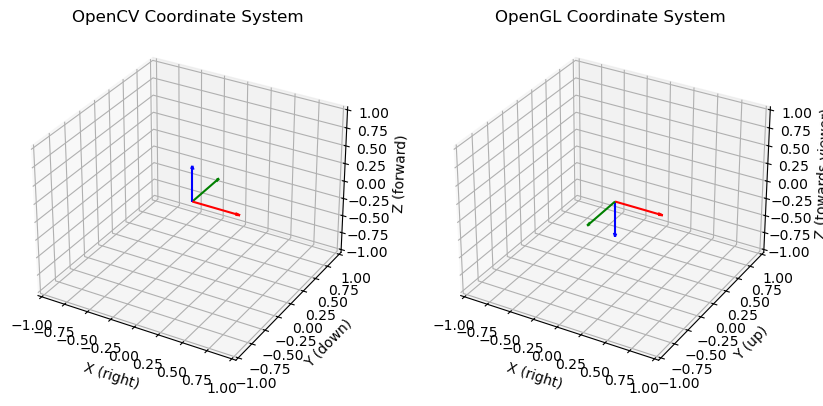

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Set up the figure and 3D axis
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Limits and labels for OpenCV axis (using left-handed coordinate system for illustration purposes)
ax1.set_xlim([-1, 1])
ax1.set_ylim([-1, 1])
ax1.set_zlim([-1, 1])
ax1.set_xlabel('X (right)')
ax1.set_ylabel('Y (down)')
ax1.set_zlabel('Z (forward)')
ax1.set_title('OpenCV Coordinate System')

# Limits and labels for OpenGL axis (right-handed coordinate system)
ax2.set_xlim([-1, 1])
ax2.set_ylim([-1, 1])
ax2.set_zlim([-1, 1])
ax2.set_xlabel('X (right)')
ax2.set_ylabel('Y (up)')
ax2.set_zlabel('Z (towards viewer)')
ax2.set_title('OpenGL Coordinate System')

# Function to draw a vector
def draw_vector(ax, start, end, color):
    arrow = np.array(end) - np.array(start)
    ax.quiver(start[0], start[1], start[2], arrow[0], arrow[1], arrow[2],
              arrow_length_ratio=0.1, color=color)

# Draw OpenCV coordinate frame
draw_vector(ax1, [0, 0, 0], [0.5, 0, 0], 'r')  # X-axis in red
draw_vector(ax1, [0, 0, 0], [0, 0.5, 0], 'g')  # Y-axis in green
draw_vector(ax1, [0, 0, 0], [0, 0, 0.5], 'b')  # Z-axis in blue

# Draw OpenGL coordinate frame
draw_vector(ax2, [0, 0, 0], [0.5, 0, 0], 'r')  # X-axis in red
draw_vector(ax2, [0, 0, 0], [0, -0.5, 0], 'g')  # Y-axis in green (inverted to match OpenCV's downward Y)
draw_vector(ax2, [0, 0, 0], [0, 0, -0.5], 'b')  # Z-axis in blue (inverted to come towards the viewer)

# Show plot
plt.show()
